# Goal Type x Reversibility effect

Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Overall Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [21]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

1. Contingency Table

In [22]:
contingency = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"]
)

contingency

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,25,16,24
goal_non_frequent,No,37,10,19
no_goal,Yes,34,12,18


2. Proportions

In [23]:
proportions = pd.crosstab(
    [subgroup_theoretical["Goal_Type"],subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,0.384615,0.246154,0.369231
goal_non_frequent,No,0.560606,0.151515,0.287879
no_goal,Yes,0.531250,0.187500,0.281250


3. Chi-Square Test

In [24]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 4.882
p-value: 0.2996
Degrees of freedom: 4


There is no evidence that response distribution differs across reversibility conditions (but X2 is higher and p-value is lower than with Reversibility on its own)

4. Expected Counts

In [25]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,32.000000,12.666667,20.333333
goal_non_frequent,No,32.492308,12.861538,20.646154
no_goal,Yes,31.507692,12.471795,20.020513


In [26]:
print(expected_df < 5)

Response_Full                               L1_transfer  L2_other  correct
Goal_Type         Consequent_Reversibility                                
goal_frequent     Yes                             False     False    False
goal_non_frequent No                              False     False    False
no_goal           Yes                             False     False    False


There aren't any groups with fewer than 5 observations.

5. Cramér's V

In [27]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.112


V = 0.122: the effect size is still very small and just slightly higher than Reversibility on its own. The magnitude of the effects remains very low. 

6. Standardized Residuals

In [28]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,-1.237437,0.936586,0.813143
goal_non_frequent,No,0.790795,-0.797909,-0.362285
no_goal,Yes,0.444011,-0.133595,-0.451569


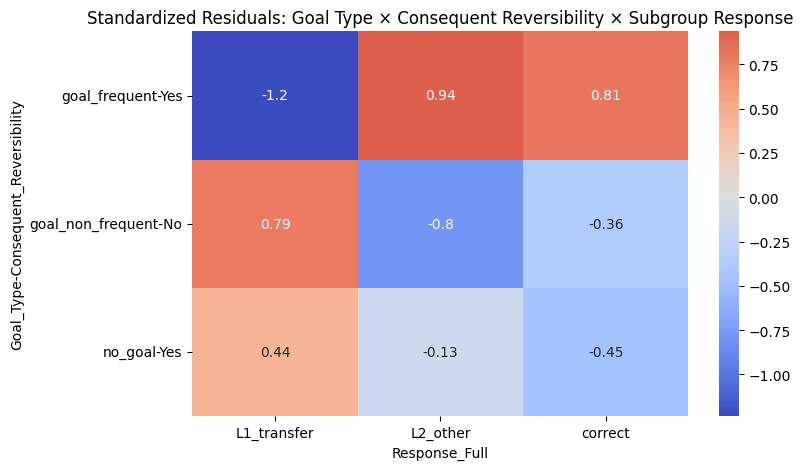

In [29]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Consequent Reversibility × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association
- Does this support the reversibility hypothesis?
- What remains unexplained?



## Actors Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [30]:
subgroup_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

1. Contingency Table

In [31]:
contingency = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"]
)

contingency

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,13,10,16
goal_non_frequent,No,18,9,13
no_goal,Yes,22,5,11


2. Proportions

In [32]:
proportions = pd.crosstab(
    [subgroup_actors["Goal_Type"],subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"],
    normalize="index"
)

proportions

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,0.333333,0.256410,0.410256
goal_non_frequent,No,0.450000,0.225000,0.325000
no_goal,Yes,0.578947,0.131579,0.289474


3. Chi-Square Test

In [33]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 5.015
p-value: 0.2857
Degrees of freedom: 4


no evidence. X2 is higher 

4. Expected Counts

In [34]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,17.666667,8.000000,13.333333
goal_non_frequent,No,18.119658,8.205128,13.675214
no_goal,Yes,17.213675,7.794872,12.991453


In [35]:
print(expected_df < 5)

Response_Full                               L1_transfer  L2_other  correct
Goal_Type         Consequent_Reversibility                                
goal_frequent     Yes                             False     False    False
goal_non_frequent No                              False     False    False
no_goal           Yes                             False     False    False


There are no groups with fewer than  observations

5. Cramér's V

In [36]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.146


V = 0.146: the effect size is still small, but higher than with the overall subgroup

6. Standardized Residuals

In [37]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

,Response_Full,L1_transfer,L2_other,correct
Goal_Type,Consequent_Reversibility,,,
goal_frequent,Yes,-1.110272,0.707107,0.730297
goal_non_frequent,No,-0.028110,0.277495,-0.182589
no_goal,Yes,1.153627,-1.001054,-0.552511


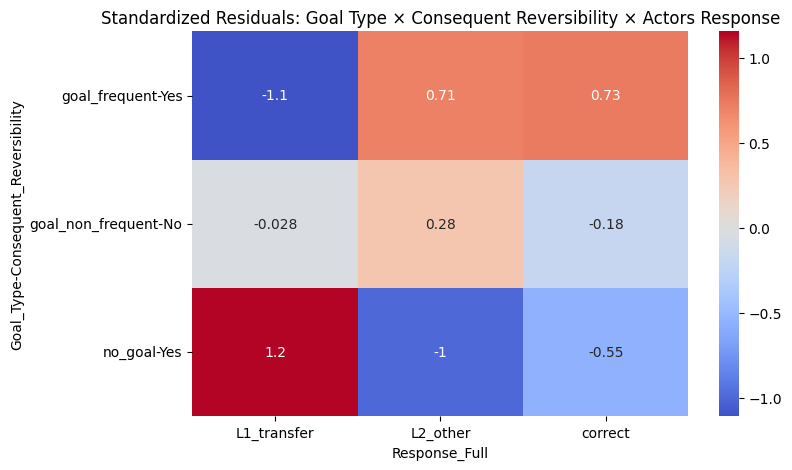

In [38]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Consequent Reversibility × Actors Response")
plt.show()

7. Interpretation